In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [8]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(
    url,
    names=columns
)

print("Dataset loaded successfully!")
df.head()


Dataset loaded successfully!


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
print("Dataset Shape:", df.shape)

Dataset Shape: (768, 9)


In [11]:
#identify invalid zero Values

zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]
for column in zero_columns:
    print(
        column,
        "zero values:",
        (df[column] == 0).sum()
    )

Glucose zero values: 5
BloodPressure zero values: 35
SkinThickness zero values: 227
Insulin zero values: 374
BMI zero values: 11


In [12]:
# replace invalid Zero with NaN
for column in zero_columns:
    print(
        column,
        "zero values:",
        (df[column] == 0).sum()
    )

print(
    df.isnull().sum()
)

Glucose zero values: 5
BloodPressure zero values: 35
SkinThickness zero values: 227
Insulin zero values: 374
BMI zero values: 11
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [13]:
# fill Missing Values
for column in zero_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )

print(
    df.isnull().sum()
)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [14]:
# check Target Distribution
print(
    df["Outcome"].value_counts()
)

Outcome
0    500
1    268
Name: count, dtype: int64


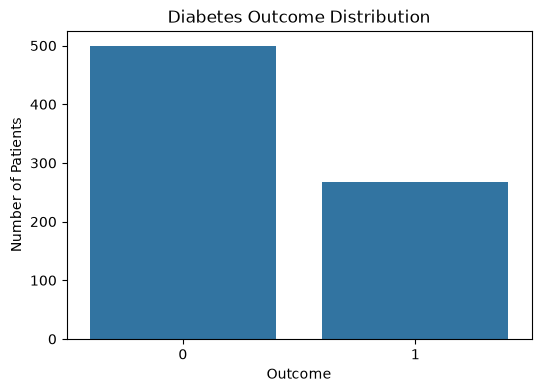

In [15]:
# visualize Target Distribution
plt.figure(figsize=(6, 4))

sns.countplot(
    x="Outcome",
    data=df
)

plt.title(
    "Diabetes Outcome Distribution"
)

plt.xlabel(
    "Outcome"
)

plt.ylabel(
    "Number of Patients"
)

plt.show()

In [17]:
# Seperate features and Target
X = df.drop(
    "Outcome",
    axis=1
)

y = df["Outcome"]
print(
    "Features Shape:",
    X.shape
)

print(
    "Target Shape:",
    y.shape
)

Features Shape: (768, 8)
Target Shape: (768,)


In [19]:
#Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(
    "Training Features:",
    X_train.shape
)

print(
    "Testing Features:",
    X_test.shape
)

print(
    "Training Target:",
    y_train.shape
)

print(
    "Testing Target:",
    y_test.shape
)

Training Features: (614, 8)
Testing Features: (154, 8)
Training Target: (614,)
Testing Target: (154,)


In [20]:
#feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [22]:
#create the five Models
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "SVM":
        SVC(
            kernel="rbf",
            random_state=42
        )
}

In [23]:
# Train All five models
results = []

predictions_dict = {}

for name, model in models.items():

    model.fit(
        X_train_scaled,
        y_train
    )

    predictions = model.predict(
        X_test_scaled
    )

    predictions_dict[name] = predictions

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1-Score": f1
    })

print(
    "All models trained successfully!"
)

All models trained successfully!


In [24]:
# create model comparison Table
results_df = pd.DataFrame(
    results
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.714286,0.608696,0.518519,0.560000
1,Decision Tree,0.720779,0.634146,0.481481,0.547368
2,Random Forest,0.759740,0.680851,0.592593,0.633663
3,KNN,0.701299,0.583333,0.518519,0.549020
4,SVM,0.753247,0.660000,0.611111,0.634615


In [25]:
# round the results
results_display = results_df.copy()

results_display[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
] = results_display[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].round(4)

results_display

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7143,0.6087,0.5185,0.5600
1,Decision Tree,0.7208,0.6341,0.4815,0.5474
2,Random Forest,0.7597,0.6809,0.5926,0.6337
3,KNN,0.7013,0.5833,0.5185,0.5490
4,SVM,0.7532,0.6600,0.6111,0.6346


In [26]:
# sort Models by f1-score
results_df.sort_values(
    by="F1-Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
4,SVM,0.753247,0.660000,0.611111,0.634615
2,Random Forest,0.759740,0.680851,0.592593,0.633663
0,Logistic Regression,0.714286,0.608696,0.518519,0.560000
3,KNN,0.701299,0.583333,0.518519,0.549020
1,Decision Tree,0.720779,0.634146,0.481481,0.547368


In [27]:
# find the best model
best_model_row = results_df.loc[
    results_df["F1-Score"].idxmax()
]

print(
    "Best Model:",
    best_model_row["Model"]
)

print(
    "Best F1-Score:",
    round(
        best_model_row["F1-Score"],
        4
    )
)

Best Model: SVM
Best F1-Score: 0.6346


In [28]:
# find the model with highest accuracy
best_accuracy_row = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print(
    "Highest Accuracy Model:",
    best_accuracy_row["Model"]
)

print(
    "Highest Accuracy:",
    round(
        best_accuracy_row["Accuracy"],
        4
    )
)

Highest Accuracy Model: Random Forest
Highest Accuracy: 0.7597


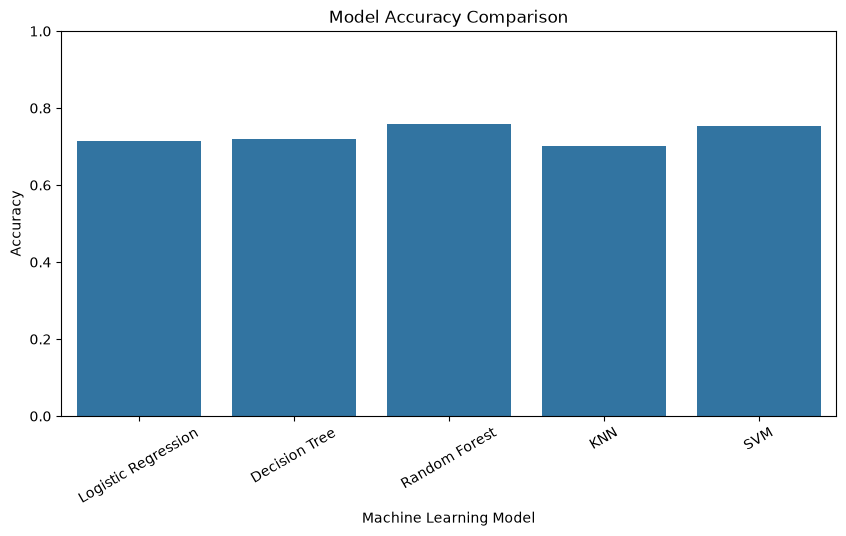

In [29]:
# compare model accuracy
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Model Accuracy Comparison"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "Accuracy"
)

plt.xticks(
    rotation=30
)

plt.ylim(
    0,
    1
)

plt.show()

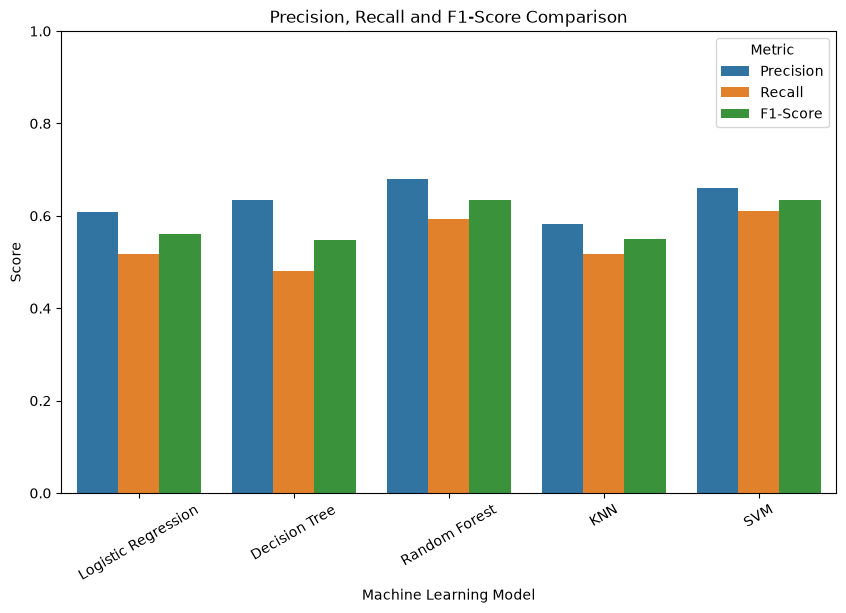

In [31]:
# compare precision recall and f1-score
metrics_df = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Precision",
        "Recall",
        "F1-Score"
    ],
    var_name="Metric",
    value_name="Score"
)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=metrics_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title(
    "Precision, Recall and F1-Score Comparison"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "Score"
)

plt.xticks(
    rotation=30
)

plt.ylim(
    0,
    1
)

plt.show()

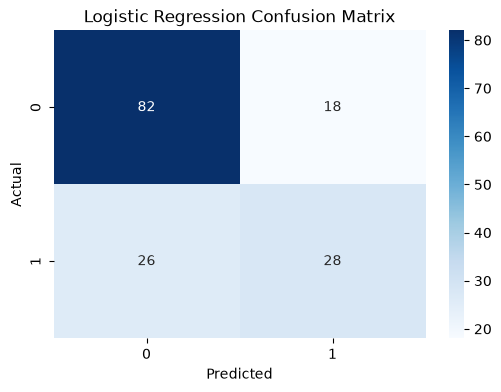

In [32]:
# confusion matrix logistic regression
cm_lr = confusion_matrix(
    y_test,
    predictions_dict[
        "Logistic Regression"
    ]
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

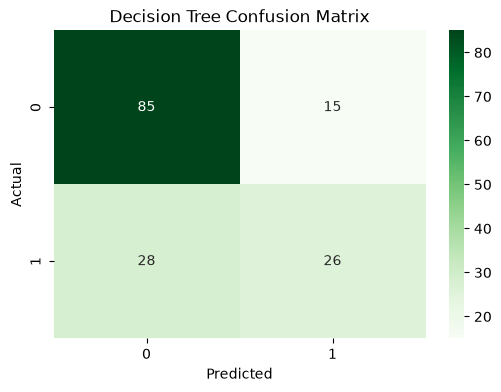

In [33]:
# confusion matrix - decision tree
cm_dt = confusion_matrix(
    y_test,
    predictions_dict[
        "Decision Tree"
    ]
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title(
    "Decision Tree Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

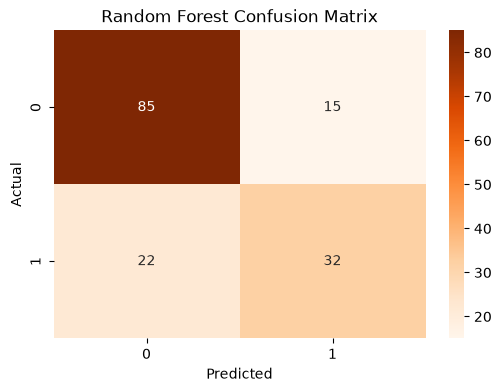

In [34]:
# confusion matrix random forest
cm_rf = confusion_matrix(
    y_test,
    predictions_dict[
        "Random Forest"
    ]
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

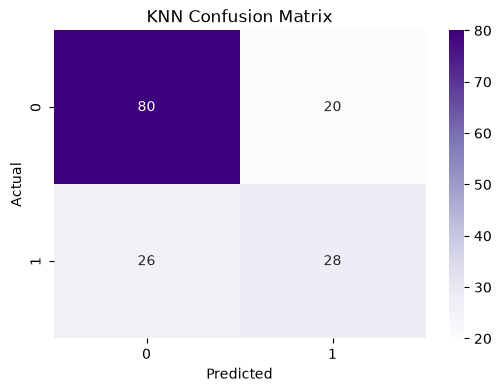

In [35]:
# confusion matrix KNN
cm_knn = confusion_matrix(
    y_test,
    predictions_dict[
        "KNN"
    ]
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title(
    "KNN Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

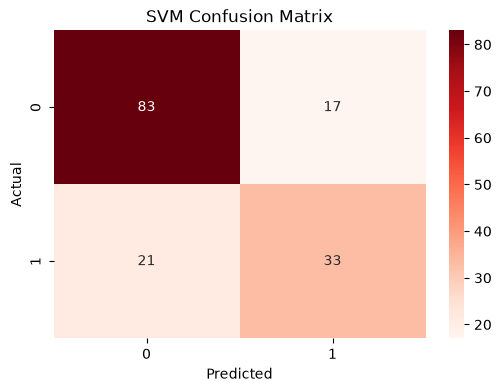

In [36]:
# confusion matix -SVM
cm_svm = confusion_matrix(
    y_test,
    predictions_dict[
        "SVM"
    ]
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title(
    "SVM Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()


In [37]:
# displaying all classification report 
for name, predictions in predictions_dict.items():

    print(
        "\n===================================="
    )

    print(
        name
    )

    print(
        "===================================="
    )

    print(
        classification_report(
            y_test,
            predictions
        )
    )


Logistic Regression
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154


Decision Tree
              precision    recall  f1-score   support

           0       0.75      0.85      0.80       100
           1       0.63      0.48      0.55        54

    accuracy                           0.72       154
   macro avg       0.69      0.67      0.67       154
weighted avg       0.71      0.72      0.71       154


Random Forest
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75

In [38]:
# create final ranking
final_ranking = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(
    drop=True
)

final_ranking.index = (
    final_ranking.index + 1
)

final_ranking


,Model,Accuracy,Precision,Recall,F1-Score
1,SVM,0.753247,0.660000,0.611111,0.634615
2,Random Forest,0.759740,0.680851,0.592593,0.633663
3,Logistic Regression,0.714286,0.608696,0.518519,0.560000
4,KNN,0.701299,0.583333,0.518519,0.549020
5,Decision Tree,0.720779,0.634146,0.481481,0.547368


In [41]:
final_results = results_df.copy()

final_results[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
] = final_results[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
].round(4)

final_results.sort_values(
    by="F1-Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
4,SVM,0.7532,0.6600,0.6111,0.6346
2,Random Forest,0.7597,0.6809,0.5926,0.6337
0,Logistic Regression,0.7143,0.6087,0.5185,0.5600
3,KNN,0.7013,0.5833,0.5185,0.5490
1,Decision Tree,0.7208,0.6341,0.4815,0.5474
